<a href="https://colab.research.google.com/github/raniverma1234/DASHBOARD-2/blob/main/predictive_maintenance_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, recall_score, confusion_matrix

In [ ]:
import os
print(os.listdir())

['.config', 'iot_sensor_telemetry .csv', 'sample_data']


In [ ]:
df = pd.read_csv("iot_sensor_telemetry .csv")
df.head()

,Timestamp,Sensor_Temp_C,Sensor_Vibration_mm,Sensor_Voltage_V,Catastrophic_Failure
0,2023-01-01 00:00:00,66.490142,1.064301,220.696572,0.0
1,2023-01-01 01:00:00,64.585207,1.138900,220.566647,0.0
2,2023-01-01 02:00:00,66.943066,1.080524,218.126960,0.0
3,2023-01-01 03:00:00,69.569090,1.222084,221.159168,0.0
4,2023-01-01 04:00:00,64.297540,1.439436,217.019835,0.0


In [ ]:
df = pd.read_csv("iot_sensor_telemetry .csv")   # apni file ka sahi naam likho
df.head()

,Timestamp,Sensor_Temp_C,Sensor_Vibration_mm,Sensor_Voltage_V,Catastrophic_Failure
0,2023-01-01 00:00:00,66.490142,1.064301,220.696572,0.0
1,2023-01-01 01:00:00,64.585207,1.138900,220.566647,0.0
2,2023-01-01 02:00:00,66.943066,1.080524,218.126960,0.0
3,2023-01-01 03:00:00,69.569090,1.222084,221.159168,0.0
4,2023-01-01 04:00:00,64.297540,1.439436,217.019835,0.0


In [ ]:
print(df.columns.tolist())

['Timestamp', 'Sensor_Temp_C', 'Sensor_Vibration_mm', 'Sensor_Voltage_V', 'Catastrophic_Failure']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             10000 non-null  object 
 1   Sensor_Temp_C         10000 non-null  float64
 2   Sensor_Vibration_mm   10000 non-null  float64
 3   Sensor_Voltage_V      10000 non-null  float64
 4   Catastrophic_Failure  10000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 390.8+ KB


In [ ]:
df.describe()

,Sensor_Temp_C,Sensor_Vibration_mm,Sensor_Voltage_V,Catastrophic_Failure
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,66.343592,1.418707,219.795432,0.001500
std,5.741879,0.804664,2.438464,0.038703
min,53.232799,0.428725,192.742881,0.000000
25%,63.179478,1.082075,218.510573,0.000000
50%,65.379926,1.227642,219.933295,0.000000
75%,67.754117,1.390217,221.301191,0.000000
max,121.663741,8.860873,227.383249,1.000000


In [ ]:
print(df["Catastrophic_Failure"].value_counts())

Catastrophic_Failure
0.0    9985
1.0      15
Name: count, dtype: int64


In [ ]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)
df.head()

,Timestamp,Sensor_Temp_C,Sensor_Vibration_mm,Sensor_Voltage_V,Catastrophic_Failure
0,2023-01-01 00:00:00,66.490142,1.064301,220.696572,0.0
1,2023-01-01 01:00:00,64.585207,1.138900,220.566647,0.0
2,2023-01-01 02:00:00,66.943066,1.080524,218.126960,0.0
3,2023-01-01 03:00:00,69.569090,1.222084,221.159168,0.0
4,2023-01-01 04:00:00,64.297540,1.439436,217.019835,0.0


In [ ]:
df["Temp_Rolling_Mean_12h"] = df["Sensor_Temp_C"].rolling(window=12).mean()
df["Vib_Rolling_Std_12h"] = df["Sensor_Vibration_mm"].rolling(window=12).std()

In [ ]:
print("Pehle:", len(df))
df = df.dropna().reset_index(drop=True)
print("Baad mein:", len(df))

Pehle: 10000
Baad mein: 9989


In [ ]:
df[["Sensor_Temp_C", "Temp_Rolling_Mean_12h", "Sensor_Vibration_mm", "Vib_Rolling_Std_12h"]].head()

,Sensor_Temp_C,Temp_Rolling_Mean_12h,Sensor_Vibration_mm,Vib_Rolling_Std_12h
0,63.602811,65.887866,1.370282,0.164662
1,65.725887,65.824178,0.936841,0.178793
2,59.260159,65.380424,1.106810,0.180102
3,59.825247,64.787272,1.364598,0.181347
4,63.313137,64.265943,1.208308,0.181415


In [ ]:
df["Failure_In_24_Hours"] = df["Catastrophic_Failure"].shift(-24)

In [ ]:
df = df.iloc[:-24].reset_index(drop=True)

In [ ]:
df = df.drop(columns=["Catastrophic_Failure"])
df["Failure_In_24_Hours"] = df["Failure_In_24_Hours"].astype(int)

In [ ]:
print(len(df))
print(df["Failure_In_24_Hours"].value_counts())

9965
Failure_In_24_Hours
0    9950
1      15
Name: count, dtype: int64


In [ ]:
pos = df.index[df["Failure_In_24_Hours"] == 1].tolist()
print("Label 1 wali rows:", pos)

Label 1 wali rows: [620, 623, 786, 1056, 1617, 2872, 3077, 4131, 4999, 6311, 7099, 7805, 9180, 9411, 9474]


In [ ]:
feature_cols = [
    "Sensor_Temp_C",
    "Sensor_Vibration_mm",
    "Sensor_Voltage_V",
    "Temp_Rolling_Mean_12h",
    "Vib_Rolling_Std_12h",
]

X = df[feature_cols]
y = df["Failure_In_24_Hours"]

In [ ]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [ ]:
print("Train rows:", len(X_train), "| Failures in train:", y_train.sum())
print("Test rows:", len(X_test), "| Failures in test:", y_test.sum())

Train rows: 7972 | Failures in train: 12
Test rows: 1993 | Failures in test: 3


In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1990
           1       0.00      0.00      0.00         3

    accuracy                           1.00      1993
   macro avg       0.50      0.50      0.50      1993
weighted avg       1.00      1.00      1.00      1993

Confusion matrix:
[[1990    0]
 [   3    0]]


In [ ]:
proba = model.predict_proba(X_test)[:, 1]

for t in [0.5, 0.3, 0.2, 0.1, 0.05]:
    pred_t = (proba >= t).astype(int)
    r = recall_score(y_test, pred_t)
    alarms = pred_t.sum()
    print(f"threshold={t} | recall={r:.2f} | total alarms={alarms}")

threshold=0.5 | recall=0.00 | total alarms=0
threshold=0.3 | recall=0.00 | total alarms=2
threshold=0.2 | recall=0.33 | total alarms=4
threshold=0.1 | recall=0.67 | total alarms=9
threshold=0.05 | recall=0.67 | total alarms=16


In [ ]:
importances = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)

print(importances.sort_values("Importance", ascending=False))

                 Feature  Importance
1    Sensor_Vibration_mm    0.378649
0          Sensor_Temp_C    0.272195
3  Temp_Rolling_Mean_12h    0.244156
4    Vib_Rolling_Std_12h    0.072329
2       Sensor_Voltage_V    0.032672


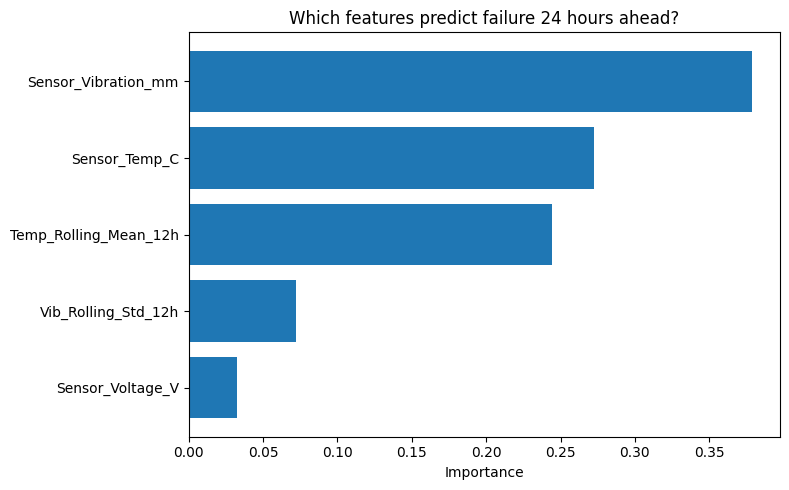

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(importances["Feature"], importances["Importance"])
plt.xlabel("Importance")
plt.title("Which features predict failure 24 hours ahead?")
plt.tight_layout()
plt.show()

In [ ]:
proba = model.predict_proba(X_test)[:, 1]

print("Asli 3 failure rows ki probability:", proba[y_test.values == 1])
print("Sabse high 10 probabilities:", np.sort(proba)[-10:])

Asli 3 failure rows ki probability: [0.025 0.28  0.175]
Sabse high 10 probabilities: [0.09  0.1   0.13  0.13  0.15  0.175 0.245 0.28  0.33  0.375]


In [ ]:
for t in [0.3, 0.2, 0.1, 0.05, 0.02]:
    pred_t = (proba >= t).astype(int)
    print(f"threshold={t} | recall={recall_score(y_test, pred_t):.2f} | total alarms={pred_t.sum()}")

threshold=0.3 | recall=0.00 | total alarms=2
threshold=0.2 | recall=0.33 | total alarms=4
threshold=0.1 | recall=0.67 | total alarms=9
threshold=0.05 | recall=0.67 | total alarms=16
threshold=0.02 | recall=1.00 | total alarms=22


In [ ]:
THRESHOLD = 0.02   # apna chuna hua threshold likho

y_final = (proba >= THRESHOLD).astype(int)

print("Threshold:", THRESHOLD)
print(classification_report(y_test, y_final, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_final))

Threshold: 0.02
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1990
           1       0.14      1.00      0.24         3

    accuracy                           0.99      1993
   macro avg       0.57      1.00      0.62      1993
weighted avg       1.00      0.99      0.99      1993

Confusion matrix:
[[1971   19]
 [   0    3]]
